### Modelos para generación de imágenes

In [1]:
# Librerías requisitos
# transformers
# accelerate
# diffusers
# uv add transformers accelerate diffusers
# modelos https://huggingface.co/models?other=diffusers%3AStableDiffusionPipeline

In [2]:
from diffusers import StableDiffusionPipeline
import torch

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

print(f"DEVICE: {DEVICE}")

modelo = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    dtype=torch.bfloat16 if DEVICE in ("cuda", "mps") else torch.float32,
    use_safetensors=True,
    low_cpu_mem_usage=False
).to(DEVICE)

/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE: mps


Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 15.27it/s]


100%|██████████| 50/50 [00:17<00:00,  2.83it/s]


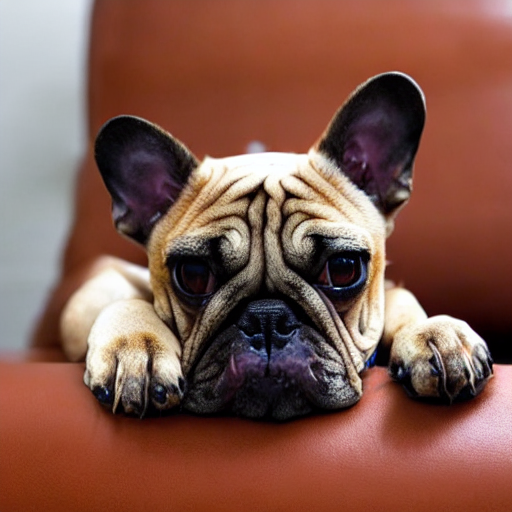

In [5]:
prompt = "A cute dog sitting on a couch"

with torch.autocast(DEVICE):
    imagen = modelo(prompt).images[0]

display(imagen)

100%|██████████| 50/50 [00:18<00:00,  2.70it/s]


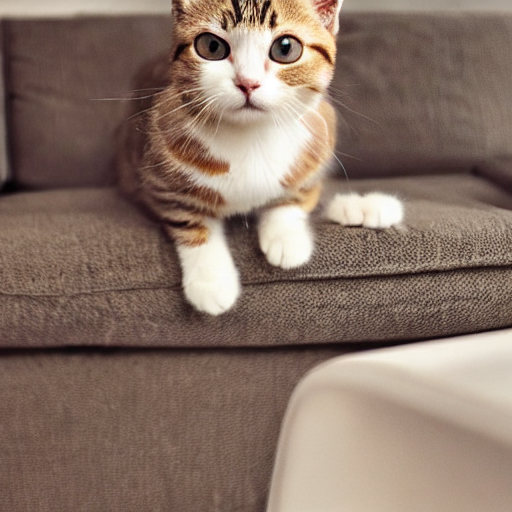

In [7]:
prompt = "A cute cat sitting on a couch"

with torch.autocast(DEVICE):
    imagen = modelo(prompt).images[0]

display(imagen)